In [14]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, random_unitary
from qiskit_aer import AerSimulator

In [12]:
def build_circuit(n, d):
    qc = QuantumCircuit(n)

    for layer in range(d):
        start = layer % 2
        for i in range(start, n - 1, 2):
            qc.append(random_unitary(4), [i, i + 1])
    return qc

def collision_prob(qc):
    psi = Statevector.from_instruction(qc)
    probs = psi.probabilities()
    cp = np.sum(probs**2)

    return cp

depth = [10]
num_qubits = list(range(2, 30))
samples_per_n = 20

for d in depth:
    avg_prob = []
    std_prob = []
    for n in num_qubits:
        vals = []
        for _ in range(samples_per_n):
            qc = build_circuit(n, d)
            cp = collision_prob(qc)
            vals.append((2**n) *cp)

        avg_prob.append(np.mean(vals))
        std_prob.append(np.std(vals))

    plt.errorbar(num_qubits, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f'Circuit depth={d}')

plt.xlabel("n (number of qubits)")
plt.ylabel(r"Collision probability $ 2^n \sum_x p_x^2$")
plt.title("1D Brickwork Circuit: Collision Probability vs Number of Qubits")
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

KeyboardInterrupt: 

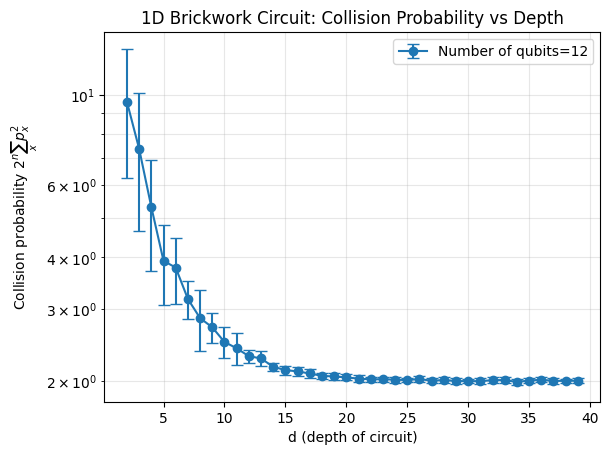

In [11]:
depth = list(range(1, 40))
num_qubits = [12]
samples_per_n = 20

for n in num_qubits:
    avg_prob = []
    std_prob = []
    for d in depth:
        vals = []
        for _ in range(samples_per_n):
            qc = build_circuit(n, d)
            cp = collision_prob(qc)
            vals.append((2**n) *cp)

        avg_prob.append(np.mean(vals))
        std_prob.append(np.std(vals))

    plt.errorbar(depth, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f'Number of qubits={n}')

plt.yscale('log')
plt.xlabel("d (depth of circuit)")
plt.ylabel(r"Collision probability $ 2^n \sum_x p_x^2$")
plt.title("1D Brickwork Circuit: Collision Probability vs Depth")
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

In [28]:
def build_circuit(n, d):
    qc = QuantumCircuit(n, n)

    for layer in range(d):
        start = layer % 2
        for i in range(start, n - 1, 2):
            qc.append(random_unitary(4), [i, i + 1])
    qc.measure(range(n), range(n))
    return qc

def collision_prob(counts, shots):
     return sum((c / shots) ** 2 for c in counts.values()) / (shots * (shots - 1))

sim = AerSimulator(
    method="matrix_product_state",
    mps_sample_measure_algorithm="mps_apply_measure",
    matrix_product_state_max_bond_dimension=64,          # try 32, 64, 128
    matrix_product_state_truncation_threshold=1e-8,      # try 1e-6 to go faster
    max_parallel_threads=0,                              # use all CPU cores
    mps_omp_threads=0                                    # let Aer choose
)

depth = [15]
num_qubits = list(range(2, 30))
shots = 20
samples_per_n = 10

for d in depth:
    avg_prob = []
    std_prob = []
    for n in num_qubits:
        vals = []
        for _ in range(samples_per_n):
            qc = build_circuit(n, d)
            tqc = transpile(qc, sim)

            result = sim.run(tqc, shots=shots).result()
            counts = result.get_counts()

            cp_est = collision_prob(counts, shots)
            vals.append((2**n) * cp_est)

        avg_prob.append(np.mean(vals))
        std_prob.append(np.std(vals))

    plt.errorbar(num_qubits, avg_prob, yerr=std_prob, marker='o', capsize=4, label=f'Circuit depth={d}')

plt.xlabel("n (number of qubits)")
plt.ylabel(r"Collision probability $ 2^n \sum_x p_x^2$")
plt.title("1D Brickwork Circuit: Collision Probability vs Number of Qubits")
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

Simulation failed and returned the following error message:
ERROR:  [Experiment 0] Insufficient memory to run circuit circuit-17652 using the matrix_product_state simulator. Required memory: 53249M, max memory: 32662M


QiskitError: 'ERROR:  [Experiment 0] Insufficient memory to run circuit circuit-17652 using the matrix_product_state simulator. Required memory: 53249M, max memory: 32662M ,  ERROR: Insufficient memory to run circuit circuit-17652 using the matrix_product_state simulator. Required memory: 53249M, max memory: 32662M'